# A3 — Thick-Walled Cylinder Stress Analysis

**Model:** Croccolo & Vincenzi (2009), *A generalized theory for shaft–hub couplings*  
**Scope:** $n$ coaxial isotropic cylinders with radial interference and rotation

---

## Validity limits

- Isotropic, linear-elastic materials ($\sigma_\text{VM} < \sigma_y$)
- Axial symmetry; same axial length and same $\omega$ for all elements
- Plane stress state ($\sigma_z = 0$): applies to *short* couplings ($L \sim D$)
- No thermal loading, no friction at interfaces, no axial force

In [3]:
import numpy as np
import matplotlib.pyplot as plt

---
## ✏️  Input — MODIFY ONLY THIS CELL

Radii are listed **from outermost to innermost**: `r[0]` is the outer radius of
the outermost element, `r[n]` is the inner bore radius (0 for a solid shaft).  
Lists must have length `n+1` (radii), `n` (material properties), `n-1` (interferences).

In [4]:
# ── MODIFY ONLY THIS CELL ──────────────────────────────────────────────────

# Number of coaxial elements
n = 3

# Radii [mm], outermost first: r[0] > r[1] > ... > r[n] >= 0
r = [35.000, 24.988, 14.995, 10.000]   # length n+1

# Young's modulus [MPa], outer element first
E  = [206000, 70000, 206000]            # length n

# Poisson's ratio [-], outer element first
nu = [0.29, 0.33, 0.29]                 # length n

# Density [kg/m³], outer element first  (used only when omega != 0)
rho = [7850, 2770, 7850]                # length n

# Total radial interference at each interface [mm]  (0 = clearance fit)
# Z_tot[0] acts at interface between elements 1 and 2, etc.
Z_tot = [0.025, 0.010]                  # length n-1

# External pressure on outermost surface [MPa]
p0 = 150.0

# Internal pressure on innermost bore [MPa]  (0 for solid shaft)
pn = 30.0

# Angular velocity [rad/s]  (0 for static case)
omega = 420.0

# ── END INPUT ───────────────────────────────────────────────────────────────

---
## Node 0 — Input validation


In [5]:
r     = np.array(r,     dtype=float)
E     = np.array(E,     dtype=float)
nu    = np.array(nu,    dtype=float)
rho   = np.array(rho,   dtype=float)
Z_tot = np.array(Z_tot, dtype=float)

assert len(r)     == n + 1, f'Expected {n+1} radii, got {len(r)}'
assert len(E)     == n,     f'Expected {n} E values, got {len(E)}'
assert len(nu)    == n,     f'Expected {n} nu values, got {len(nu)}'
assert len(rho)   == n,     f'Expected {n} rho values, got {len(rho)}'
assert len(Z_tot) == n - 1, f'Expected {n-1} interferences, got {len(Z_tot)}'
assert np.all(np.diff(r) < 0), 'Radii must be strictly decreasing'
assert r[-1] >= 0, 'Inner radius must be >= 0'

print('Input validation passed.')
print(f'  n = {n} elements')
print(f'  r = {r} mm')
print(f'  omega = {omega} rad/s')

Input validation passed.
  n = 3 elements
  r = [35.    24.988 14.995 10.   ] mm
  omega = 420.0 rad/s


---
## Node 1 — Geometric ratios

$$Q_i = \frac{r_i}{r_{i-1}}, \quad i = 1, \ldots, n$$

For a solid shaft ($r_n = 0$): $Q_n = 0$. All subsequent Lamé expressions
depend only on $Q$ and local pressures, making the formulation uniform.

In [6]:
# Q[i] = r[i] / r[i-1],  i = 1..n  (1-based; Q[0] unused)
Q = np.zeros(n + 1)
for i in range(1, n + 1):
    Q[i] = r[i] / r[i - 1] if r[i - 1] > 0 else 0.0

print('Geometric ratios Q[1..n]:')
for i in range(1, n + 1):
    print(f'  Q[{i}] = {Q[i]:.6f}')

Geometric ratios Q[1..n]:
  Q[1] = 0.713943
  Q[2] = 0.600088
  Q[3] = 0.666889


---
## Node 2 — Compatibility coefficients K, L, N  (eqs. 8–10)

These are the coefficients of the radial-displacement compatibility equation
at each interface $i = 1, \ldots, n-1$:

$$K_i\,p_i - L_i\,p_{i-1} - N_{i+1}\,p_{i+1} = \frac{Z_i}{r_i} + V_i$$

$$K_i = \frac{1}{E_i}\!\left(\frac{1+Q_i^2}{1-Q_i^2}+\nu_i\right)+\frac{1}{E_{i+1}}\!\left(1-\nu_{i+1}+\frac{2Q_{i+1}^2}{1-Q_{i+1}^2}\right)$$

$$L_i = \frac{2}{E_i(1-Q_i^2)}, \qquad N_{i+1} = \frac{2Q_{i+1}^2}{E_{i+1}(1-Q_{i+1}^2)}$$

Special case $Q_{i+1}=0$ (solid shaft): $N_{i+1}=0$, second term of $K_i$
reduces to $(1-\nu_{i+1})/E_{i+1}$.

In [7]:
# 1-based arrays; index 0 unused
K  = np.zeros(n + 1)   # K[1..n-1]
L  = np.zeros(n + 1)   # L[1..n-1]
Nv = np.zeros(n + 1)   # N[2..n]  (Nv to avoid shadowing built-in)

for i in range(1, n):           # interfaces 1 .. n-1
    ei   = E[i - 1];  nui  = nu[i - 1]
    ei1  = E[i];      nui1 = nu[i]
    Qi   = Q[i];      Qi1  = Q[i + 1]

    L[i] = 2.0 / (ei * (1.0 - Qi**2))

    if Qi1 == 0.0:             # solid shaft: simplified K, N=0
        K[i]    = (1.0/ei) * ((1.0 + Qi**2)/(1.0 - Qi**2) + nui) \
                + (1.0/ei1) * (1.0 - nui1)
        Nv[i+1] = 0.0
    else:
        K[i]    = (1.0/ei) * ((1.0 + Qi**2)/(1.0 - Qi**2) + nui) \
                + (1.0/ei1) * (1.0 - nui1 + 2.0*Qi1**2/(1.0 - Qi1**2))
        Nv[i+1] = 2.0*Qi1**2 / (ei1 * (1.0 - Qi1**2))

print('K, L, N at each interface:')
for i in range(1, n):
    print(f'  Interface {i}: K={K[i]:.6e}  L={L[i]:.6e}  N[{i+1}]={Nv[i+1]:.6e}')

K, L, N at each interface:
  Interface 1: K=4.200584e-05  L=1.980221e-05  N[2]=1.607880e-05
  Interface 2: K=4.630172e-05  L=4.465023e-05  N[3]=7.776320e-06


---
## Node 3 — Dynamic compatibility contribution V  (eq. 29)

$V_i = 0$ for all $i$ when $\omega = 0$. For the rotating case:

$$V_i = \frac{\rho_{i+1}\,\omega^2 r_i^2}{E_{i+1}} \cdot \frac{3+\nu_{i+1}}{8}\!\left(1+2Q_{i+1}^2-\frac{1+3\nu_{i+1}}{3+\nu_{i+1}}\right)
- \frac{\rho_i\,\omega^2 r_{i-1}^2}{E_i} \cdot \frac{3+\nu_i}{8}\!\left(2+Q_i^2-\frac{1+3\nu_i}{3+\nu_i}Q_i^2\right)$$

Unit note: $\rho$ in kg/m³, $r$ in mm, $E$ in MPa. Compact conversion factor:
$\rho[\text{kg/m}^3]\,\omega^2[\text{s}^{-2}]\,r^2[\text{mm}^2] \times 10^{-12} = \text{MPa}$,
then dividing by $E[\text{MPa}]$ gives the dimensionless $V_i$.

In [8]:
V = np.zeros(n + 1)   # V[1..n-1]

if omega == 0.0:
    print('Static case: V[i] = 0 for all i.')
else:
    for i in range(1, n):        # interfaces 1 .. n-1
        ri   = r[i];     ri_1 = r[i - 1]
        ei   = E[i-1];   nui  = nu[i-1];  rhoi  = rho[i-1]
        ei1  = E[i];     nui1 = nu[i];    rhoi1 = rho[i]
        Qi   = Q[i];     Qi1  = Q[i+1]

        # Factor: rho * omega^2 * r_mm^2 * 1e-12 = MPa (see unit note above)
        term_ext = (rhoi1 * omega**2 * ri**2   * 1e-12) \
                 * (3.0 + nui1) / 8.0 / ei1 \
                 * (1.0 + 2.0*Qi1**2 - (1.0 + 3.0*nui1)/(3.0 + nui1))

        term_int = (rhoi  * omega**2 * ri_1**2 * 1e-12) \
                 * (3.0 + nui) / 8.0 / ei \
                 * (2.0 + Qi**2 - (1.0 + 3.0*nui)/(3.0 + nui) * Qi**2)

        V[i] = term_ext - term_int

    print('Dynamic compatibility contributions V[1..n-1]:')
    for i in range(1, n):
        print(f'  V[{i}] = {V[i]:.6e}  [-]  (same units as Z_tot/r)')

Dynamic compatibility contributions V[1..n-1]:
  V[1] = -5.481181e-06  [-]  (same units as Z_tot/r)
  V[2] = -3.070232e-06  [-]  (same units as Z_tot/r)


---
## Node 4 — Forward sweep: H, I, J  (eqs. 34–39)

Reduces the $(n-1) \times (n-1)$ tridiagonal system to upper-bidiagonal form.
Propagates boundary conditions from the outer surface inward.

Initialisation ($i=1$):
$$H_1 = K_1, \quad I_2 = N_2, \quad J_1 = L_1 p_0 + \frac{Z_1}{r_1} + V_1$$

Recursion ($i = 2, \ldots, n-1$):
$$H_i = \frac{K_i}{L_i} H_{i-1} - I_i, \qquad
I_{i+1} = \frac{N_{i+1}}{L_i} H_{i-1}, \qquad
J_i = J_{i-1} + \frac{H_{i-1}}{L_i}\!\left(\frac{Z_i}{r_i} + V_i\right)$$

In [9]:
# 1-based arrays; index 0 unused
H  = np.zeros(n + 1)   # H[1..n-1]
Iv = np.zeros(n + 1)   # I[2..n]
J  = np.zeros(n + 1)   # J[1..n-1]

# Initialisation at interface i=1
H[1]  = K[1]
Iv[2] = Nv[2]
J[1]  = p0 * L[1] + Z_tot[0] / r[1] + V[1]

# Recursion for interfaces i = 2 .. n-1
for i in range(2, n):
    H[i]    = (K[i] / L[i]) * H[i-1] - Iv[i]
    Iv[i+1] = (Nv[i+1] / L[i]) * H[i-1]
    J[i]    = J[i-1] + (H[i-1] / L[i]) * (Z_tot[i-1] / r[i] + V[i])

print('Forward sweep results:')
for i in range(1, n):
    print(f'  H[{i}]={H[i]:.6e}  I[{i+1}]={Iv[i+1]:.6e}  J[{i}]={J[i]:.6e}')

Forward sweep results:
  H[1]=4.200584e-05  I[2]=1.607880e-05  J[1]=3.965330e-03
  H[2]=2.748072e-05  I[3]=7.315771e-06  J[2]=4.589835e-03


---
## Node 5 — Back-substitution: interface pressures  (eq. 40)

Solve the bidiagonal system from the innermost interface outward:

$$p_{n-1} = \frac{J_{n-1} + p_n\,I_n}{H_{n-1}}, \qquad
p_{i-1} = \frac{p_i\,I_i + J_{i-1}}{H_{i-1}}, \quad i = n-1, \ldots, 2$$

Array `p_int[0..n]` stores: $p_0$ (external, input), $p_1,\ldots,p_{n-1}$
(contact pressures, computed), $p_n$ (bore, input).

In [10]:
p_int = np.zeros(n + 1)
p_int[0] = p0
p_int[n] = pn

# Innermost interface first
p_int[n-1] = (J[n-1] + pn * Iv[n]) / H[n-1]

# Back-substitute outward
for i in range(n-1, 1, -1):
    p_int[i-1] = (p_int[i] * Iv[i] + J[i-1]) / H[i-1]

print('Interface pressures:')
print(f'  p0  (external)  = {p_int[0]:10.4f} MPa  [input]')
for i in range(1, n):
    print(f'  p{i}  (contact)   = {p_int[i]:10.4f} MPa')
print(f'  p{n}  (bore)       = {p_int[n]:10.4f} MPa  [input]')

Interface pressures:
  p0  (external)  =   150.0000 MPa  [input]
  p1  (contact)   =   161.3877 MPa
  p2  (contact)   =   175.0066 MPa
  p3  (bore)       =    30.0000 MPa  [input]


---
## Node 6 — Stress distributions  (eqs. 2 + 25)

For element $i$ at radius $r_g$ ($r_i \leq r_g \leq r_{i-1}$), let $Q_g = r_g/r_{i-1}$.

**Static Lamé:**
$$\sigma_r^{(s)} = -p_{i-1} + (p_i-p_{i-1})\frac{Q_i^2}{1-Q_i^2}\!\left(1-Q_g^{-2}\right), \qquad
\sigma_\theta^{(s)} = -p_{i-1} + (p_i-p_{i-1})\frac{Q_i^2}{1-Q_i^2}\!\left(1+Q_g^{-2}\right)$$

**Dynamic** ($\omega\neq 0$), with $C_i = \rho_i\,\omega^2 r_{i-1}^2\times 10^{-12}\,(3+\nu_i)/8$:
$$\sigma_r^{(d)} = C_i\!\left(1+Q_i^2-Q_i^2 Q_g^{-2}-Q_g^2\right), \qquad
\sigma_\theta^{(d)} = C_i\!\left(1+Q_i^2+Q_i^2 Q_g^{-2}-\tfrac{1+3\nu_i}{3+\nu_i}Q_g^2\right)$$

**Von Mises** (plane stress): $\sigma_\text{VM} = \sqrt{\sigma_r^2+\sigma_\theta^2-\sigma_r\sigma_\theta}$

In [11]:
N_PTS = 60    # radial points per element (for smooth curves)

# Storage for plots
r_plot     = []
sig_r_plot = []
sig_t_plot = []
elem_bands = []   # (r_inner, r_outer, index) for shading

# Summary table: [sig_r_int, sig_r_ext, sig_t_int, sig_t_ext, VM_int, VM_ext]
results = np.zeros((n, 6))

def von_mises(sr, st):
    return np.sqrt(sr**2 + st**2 - sr*st)

for i in range(1, n + 1):       # element index, 1-based
    r_outer = r[i - 1]
    r_inner = r[i]
    Qi      = Q[i]
    pi_out  = p_int[i - 1]       # outer-face pressure
    pi_in   = p_int[i]           # inner-face pressure
    nui     = nu[i - 1]
    rhoi    = rho[i - 1]

    # Centrifugal coefficient [MPa] (factor 1e-12 for rho kg/m³, r mm, E MPa)
    Ci = rhoi * omega**2 * r_outer**2 * 1e-12 * (3.0 + nui) / 8.0

    r_arr     = np.linspace(r_outer, r_inner, N_PTS)
    sig_r_arr = np.zeros(N_PTS)
    sig_t_arr = np.zeros(N_PTS)

    for k, rg in enumerate(r_arr):
        Qg = rg / r_outer

        if Qi == 0.0:            # solid shaft: uniform biaxial state
            sig_r_s = -pi_in
            sig_t_s = -pi_in
            sig_r_d = 0.0
            sig_t_d = 0.0
        else:
            fac     = (pi_in - pi_out) * Qi**2 / (1.0 - Qi**2)
            sig_r_s = -pi_out + fac * (1.0 - 1.0/Qg**2)
            sig_t_s = -pi_out + fac * (1.0 + 1.0/Qg**2)
            sig_r_d = Ci * (1.0 + Qi**2 - Qi**2/Qg**2 - Qg**2)
            sig_t_d = Ci * (1.0 + Qi**2 + Qi**2/Qg**2
                            - (1.0 + 3.0*nui)/(3.0 + nui) * Qg**2)

        sig_r_arr[k] = sig_r_s + sig_r_d
        sig_t_arr[k] = sig_t_s + sig_t_d

    # Store for plotting
    r_plot.append(r_arr)
    sig_r_plot.append(sig_r_arr)
    sig_t_plot.append(sig_t_arr)
    elem_bands.append((r_inner, r_outer, i))

    # Boundary values: linspace goes outer→inner, so
    # index 0 = outer surface = _ext, index -1 = inner surface = _int
    results[i-1] = [
        sig_r_arr[-1],  sig_r_arr[0],
        sig_t_arr[-1],  sig_t_arr[0],
        von_mises(sig_r_arr[-1], sig_t_arr[-1]),
        von_mises(sig_r_arr[0],  sig_t_arr[0])
    ]

print('Stress computation done.')

Stress computation done.


---
## Node 7 — Output tables


In [12]:
# ── Pressure table ──────────────────────────────────────────────────────
print('─'*46)
print('  Interface pressures')
print('─'*46)
print(f"  {'Interface':>12}  {'Pressure [MPa]':>14}")
print('─'*46)
lbl = {0: '(external)', n: '(bore)'}
for i in range(n + 1):
    print(f"  p{i:<11}  {p_int[i]:>14.4f}  {lbl.get(i,'')}")
print('─'*46)
print()

# ── Stress table ─────────────────────────────────────────────────────────
COL = 11
hdr = (f"{'Elem':>4}  {'sig_r_int':>{COL}}  {'sig_r_ext':>{COL}}"
       f"  {'sig_t_int':>{COL}}  {'sig_t_ext':>{COL}}"
       f"  {'VM_int':>{COL}}  {'VM_ext':>{COL}}")
SEP = '─' * len(hdr)
print(SEP)
print('  Stresses at element boundaries [MPa]')
print(SEP)
print(hdr)
print(SEP)
for i in range(n):
    v = results[i]
    print(f"{i+1:>4}  {v[0]:>{COL}.2f}  {v[1]:>{COL}.2f}"
          f"  {v[2]:>{COL}.2f}  {v[3]:>{COL}.2f}"
          f"  {v[4]:>{COL}.2f}  {v[5]:>{COL}.2f}")
print(SEP)

──────────────────────────────────────────────
  Interface pressures
──────────────────────────────────────────────
     Interface  Pressure [MPa]
──────────────────────────────────────────────
  p0                  150.0000  (external)
  p1                  161.3877  
  p2                  175.0066  
  p3                   30.0000  (bore)
──────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────────────────
  Stresses at element boundaries [MPa]
──────────────────────────────────────────────────────────────────────────────────
Elem    sig_r_int    sig_r_ext    sig_t_int    sig_t_ext       VM_int       VM_ext
──────────────────────────────────────────────────────────────────────────────────
   1      -161.39      -150.00      -113.39      -125.31       143.54       139.31
   2      -175.01      -161.39      -132.17      -145.92       158.00       154.24
   3       -30.00      -175.01      -552.02      -407.13       537.65    

---
## Node 7 — Stress distribution plot


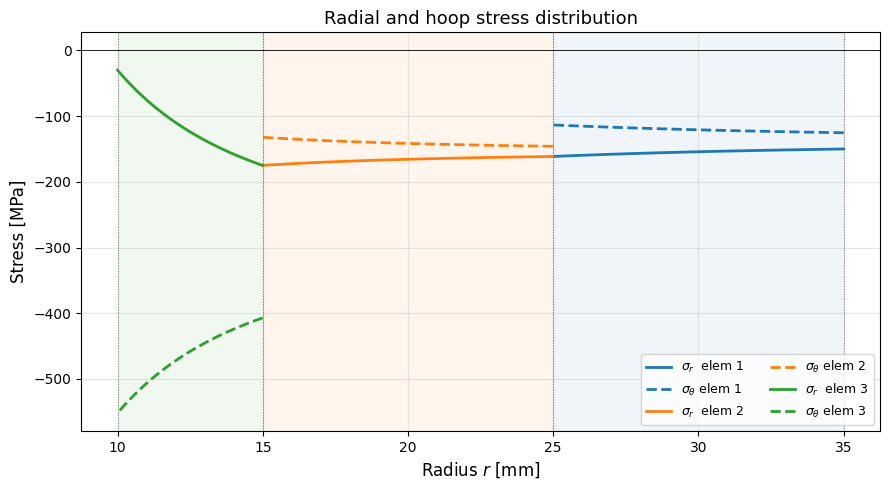

Figure saved: a3_stress_distribution.png


In [13]:
COLORS = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(9, 5))

for idx, (r_arr, sr, st) in enumerate(zip(r_plot, sig_r_plot, sig_t_plot)):
    c = COLORS[idx % len(COLORS)]
    r_in, r_out, elem_i = elem_bands[idx]

    ax.axvspan(r_in, r_out, alpha=0.07, color=c)
    ax.plot(r_arr, sr, color=c, lw=2.0, ls='-',
            label=f'$\\sigma_r$  elem {elem_i}')
    ax.plot(r_arr, st, color=c, lw=2.0, ls='--',
            label=f'$\\sigma_\\theta$ elem {elem_i}')

    for x in [r_out, r_in]:
        ax.axvline(x, color='grey', lw=0.7, ls=':')

ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('Radius $r$ [mm]', fontsize=12)
ax.set_ylabel('Stress [MPa]', fontsize=12)
ax.set_title('Radial and hoop stress distribution', fontsize=13)
ax.legend(fontsize=9, ncol=2, loc='best')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('a3_stress_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: a3_stress_distribution.png')

---
## Verification — Croccolo & Vincenzi (2009), Tables 1 & 2

Reference case: 3-element steel–aluminium–steel assembly,
$p_0=150\,\text{MPa}$, $p_n=30\,\text{MPa}$, $\omega=420\,\text{rad/s}$.

| Interface | $p$ [MPa] |
|:---------:|:---------:|
| $p_1$     | 161.39    |
| $p_2$     | 175.01    |

| Elem | $\sigma_{r,i}$ | $\sigma_{r,e}$ | $\sigma_{\theta,i}$ | $\sigma_{\theta,e}$ | VM$_i$ | VM$_e$ |
|:----:|:------:|:------:|:------:|:------:|:------:|:------:|
| 1 | −161.39 | −150.00 | −113.38 | −125.31 | 143.54 | 139.31 |
| 2 | −175.00 | −161.39 | −132.17 | −145.92 | 158.01 | 154.24 |
| 3 |  −30.00 | −175.01 | −552.03 | −407.13 | 537.65 | 353.74 |

In [14]:
p_ref = [161.39, 175.01]

stress_ref = np.array([
    [-161.39, -150.00, -113.38, -125.31,  143.54,  139.31],
    [-175.00, -161.39, -132.17, -145.92,  158.01,  154.24],
    [ -30.00, -175.01, -552.03, -407.13,  537.65,  353.74],
])

print('─'*62)
print('  Pressure verification')
print('─'*62)
print(f"  {'':4}  {'Calculated [MPa]':>16}  {'Reference [MPa]':>15}  {'Err %':>7}")
print('─'*62)
for i, pr in enumerate(p_ref):
    calc = p_int[i + 1]
    err  = abs(calc - pr) / abs(pr) * 100
    print(f"  p{i+1}:  {calc:>16.4f}  {pr:>15.4f}  {err:>6.3f}%")
print('─'*62)
print()

labels = ['sig_r_int', 'sig_r_ext', 'sig_t_int', 'sig_t_ext', 'VM_int', 'VM_ext']
print('─'*80)
print('  Stress verification')
print('─'*80)
print(f"  {'':6}  {'Quantity':>10}  {'Calc':>10}  {'Reference':>10}  {'Err %':>8}")
print('─'*80)
for i in range(n):
    for j, lbl in enumerate(labels):
        calc = results[i, j]
        ref  = stress_ref[i, j]
        denom = abs(ref) if abs(ref) > 1e-6 else 1.0
        err  = abs(calc - ref) / denom * 100
        print(f"  elem {i+1}  {lbl:>10}  {calc:>10.2f}  {ref:>10.2f}  {err:>7.3f}%")
    if i < n - 1:
        print('  ' + '·'*78)
print('─'*80)

──────────────────────────────────────────────────────────────
  Pressure verification
──────────────────────────────────────────────────────────────
        Calculated [MPa]  Reference [MPa]    Err %
──────────────────────────────────────────────────────────────
  p1:          161.3877         161.3900   0.001%
  p2:          175.0066         175.0100   0.002%
──────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
  Stress verification
────────────────────────────────────────────────────────────────────────────────
            Quantity        Calc   Reference     Err %
────────────────────────────────────────────────────────────────────────────────
  elem 1   sig_r_int     -161.39     -161.39    0.001%
  elem 1   sig_r_ext     -150.00     -150.00    0.000%
  elem 1   sig_t_int     -113.39     -113.38    0.005%
  elem 1   sig_t_ext     -125.31     -125.31    0.000%
  elem 1      VM_int      143.54

---
## How to use this notebook

### On Google Colab
1. Open [Google Colab](https://colab.research.google.com) and upload this file,
   or open directly from GitHub via **File → Open notebook → GitHub**.
2. Run **Runtime → Run all** (`Ctrl+F9`).
3. Edit only the **Input cell** (marked `✏️`) and re-run all.

### Parameter reference

| Parameter | Symbol | Unit | Notes |
|:----------|:------:|:----:|:------|
| Number of elements | `n` | — | ≥ 2 |
| Radii (outer→inner) | `r` | mm | `r[n]` = 0 for solid shaft; length `n+1` |
| Young's modulus | `E` | MPa | length `n` |
| Poisson's ratio | `nu` | — | length `n` |
| Density | `rho` | kg/m³ | needed only when `omega` ≠ 0; length `n` |
| Radial interference | `Z_tot` | mm | 0 = clearance fit; length `n-1` |
| External pressure | `p0` | MPa | applied to outermost surface |
| Bore pressure | `pn` | MPa | 0 for solid shaft |
| Angular velocity | `omega` | rad/s | 0 for static case |

### Known limitations

- All elements share the **same axial length** and the **same $\omega$**
- Valid only in the **elastic range**: always verify $\sigma_\text{VM} < \sigma_y$
- Plane stress ($\sigma_z=0$) is accurate for $L \sim D$;
  long couplings require plane-strain corrections
- No thermal loading, no friction, no axial force